# Projet 4 — Deep Learning pour la prédiction d’épidémies
## Modèle hybride LSTM + SIR

===============================================

### Projet 4 : redigé par : 
    1. Houssein Robleh ABDI-SALAM
    2. Lyonel Sydney DINZEBI
===============================================

Ce notebook couvre les étapes suivantes :

1. **Étape 1 :** Implémenter un modèle hybride LSTM + SIR différentiable.
2. **Étape 2 :** Générer des données simulées avec un taux de transmission β(t) variable et bruité.
3. **Étape 3 :** Entraîner le modèle hybride à prédire l’incidence future avec une perte MSE + régularisation.
4. **Étape 4 :** Comparer le modèle hybride avec :
   - un LSTM pur ;
   - un SIR classique recalibré.

Livrables ajoutés :

- courbes de prédiction moyenne ± écart-type pour les horizons 7 jours et 14 jours ;
- tableau comparatif RMSE et MAE ;
- discussion sur l’interprétabilité : ce que le RNN capture que le SIR seul ne capture pas.

# 0. Installation et importation des bibliothèques

Si `torchdiffeq` n’est pas installé, on peut l’installer, mais ce notebook utilise volontairement un solveur SIR discret de type Euler pour garder le code simple et robuste.

Ce solveur reste différentiable, car toutes les opérations sont réalisées avec des tenseurs PyTorch.

In [3]:
# À exécuter seulement si nécessaire
!pip install torchdiffeq

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Reproductibilité des résultats
np.random.seed(42)
torch.manual_seed(42)

# Configuration générale
#On simule une épidémie de 220 jours dans une population de 100 000 personnes.
#Le modèle regarde 21 jours d’historique pour prédire les 14 jours suivants.
#Il apprend sur 75% des données et il est évalué sur les 25% restants.
N_POP = 100000
T = 220
WINDOW = 21
HORIZON = 14
TRAIN_RATIO = 0.75

   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/123.0 MB 1.2 MB/s eta 0:01:43
   ---------------------------------------- 0.8/123.0 MB 1.0 MB/s eta 0:02:01
   ---------------------------------------- 1.0/123.0 MB 1.1 MB/s eta 0:01:47
   ---------------------------------------- 1.3/123.0 MB 1.2 MB/s eta 0:01:44
    --------------------------------------- 1.6/123.0 MB 1.1 MB/s eta 0:01:49
    --------------------------------------- 1.8/123.0 MB 1.2 MB/s eta 0:01:44
    --------------------------------------- 2.1/123.0 MB 1.2 MB/s eta 0:01:42
    --------------------------------------- 2.4/123.0 MB 1.2 MB/s eta 0:01:41
    --------------------------------------- 2.6/123.0 MB 1.2 MB/s eta 0:01:41
    --------------------------------------- 2.9/123.0 MB 1.2 MB/s eta 0:01:40
   - --

# Étape 1 — Implémentation du modèle hybride LSTM + SIR

## 1.1 Rappel du modèle SIR

Le modèle SIR est défini par trois compartiments :

- **S(t)** : population susceptible ;
- **I(t)** : population infectée ;
- **R(t)** : population retirée, guérie ou non infectieuse.

La dynamique est contrôlée par :

- **β(t)** : taux de transmission ;
- **γ(t)** : taux de guérison ou de sortie de l’état infectieux.

Dans le modèle hybride, le LSTM apprend β(t) et γ(t), puis ces paramètres alimentent le modèle SIR.

In [9]:
def euler_sir_forecast(y0, beta, gamma, N, horizon=14):
    '''
    Prévision SIR discrète sur un horizon donné.

    y0 : tensor de forme [batch, 3]
        État initial S, I, R.
    beta : tensor de forme [batch]
        Taux de transmission estimé.
    gamma : tensor de forme [batch]
        Taux de guérison estimé.
    N : int ou float
        Population totale.
    horizon : int
        Nombre de jours à prédire.

    Retour :
    incidences : tensor de forme [batch, horizon]
        Cas incidents prédits pour chaque jour futur.
    '''

    S = y0[:, 0]
    I = y0[:, 1]
    R = y0[:, 2]

    incidences = []

    for _ in range(horizon):
        new_infections = beta * S * I / N
        recoveries = gamma * I

        S = S - new_infections
        I = I + new_infections - recoveries
        R = R + recoveries

        incidences.append(torch.clamp(new_infections, min=0))

    incidences = torch.stack(incidences, dim=1)

    return incidences

In [11]:
class ParameterLSTM(nn.Module):
    '''
    Ce réseau LSTM reçoit les observations historiques et prédit les paramètres
    épidémiologiques beta et gamma.
    '''

    def __init__(self, input_dim, hidden_dim=64, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        '''
        x : tensor [batch, window, input_dim]
        '''

        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]

        last_hidden = self.dropout(last_hidden)

        params = self.fc(last_hidden)

        # softplus garantit des valeurs positives
        beta = F.softplus(params[:, 0]) + 1e-5
        gamma = F.softplus(params[:, 1]) + 1e-5

        return beta, gamma

In [13]:
class HybridLSTMSIR(nn.Module):
    '''
    Modèle hybride :
    LSTM -> beta, gamma -> SIR -> incidence future.
    '''

    def __init__(self, input_dim, hidden_dim=64, N=100000, horizon=14, dropout=0.2):
        super().__init__()

        self.parameter_net = ParameterLSTM(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            dropout=dropout
        )

        self.N = N
        self.horizon = horizon

    def forward(self, x, y0):
        '''
        x  : variables historiques [batch, window, input_dim]
        y0 : état initial S, I, R [batch, 3]
        '''

        beta, gamma = self.parameter_net(x)

        incidence_pred = euler_sir_forecast(
            y0=y0,
            beta=beta,
            gamma=gamma,
            N=self.N,
            horizon=self.horizon
        )

        return incidence_pred, beta, gamma

# Étape 2 — Génération des données simulées

Dans un cas réel, les paramètres β(t) et γ(t) ne sont pas observés directement.  
On commence donc par une simulation pour vérifier que le modèle fonctionne.

On génère une épidémie artificielle dans laquelle β(t) dépend :

- d’une composante saisonnière ;
- de la mobilité ;
- des mesures sanitaires ;
- d’un bruit aléatoire.

### Modèle SIR de référence
Le modèle SIR (Susceptible-Infectieux-Rétabli) est décrit par :

$$\frac{dS}{dt} = -\frac{\beta(t) \cdot S \cdot I}{N}$$

$$\frac{dI}{dt} = \frac{\beta(t) \cdot S \cdot I}{N} - \gamma \cdot I$$

$$\frac{dR}{dt} = \gamma \cdot I$$

### β(t) dynamique (inconnu)
$$\beta(t) = 0.25 + 0.08\sin\left(\frac{2\pi t}{60}\right) - 0.0003t + 0.05\sin\left(\frac{2\pi t}{14}\right)$$

Combine : saisonnalité lente + tendance décroissante + mobilité hebdomadaire + bruit.

In [15]:
def generate_synthetic_epidemic(T=220, N=100000):
    '''
    Génère une épidémie simulée avec :
    - cas incidents ;
    - température ;
    - mobilité ;
    - mesures sanitaires ;
    - beta(t) et gamma(t) réels simulés ;
    - compartiments S, I, R.
    '''

    t = np.arange(T)

    # Variables exogènes simulées
    temperature = 25 + 3 * np.sin(2 * np.pi * t / 30) + np.random.normal(0, 0.5, T)

    mobility = (
        1
        + 0.25 * np.sin(2 * np.pi * t / 45)
        + np.random.normal(0, 0.05, T)
    )

    measures = np.zeros(T)
    measures[60:100] = 1
    measures[145:175] = 1

    # Taux de transmission variable et bruité
    beta_t = (
        0.22
        + 0.05 * np.sin(2 * np.pi * t / 40)
        + 0.10 * mobility
        - 0.09 * measures
        + np.random.normal(0, 0.015, T)
    )

    beta_t = np.clip(beta_t, 0.03, 0.60)

    # Taux de guérison légèrement variable
    gamma_t = 0.10 + 0.01 * np.sin(2 * np.pi * t / 60)
    gamma_t = np.clip(gamma_t, 0.05, 0.25)

    S = np.zeros(T)
    I = np.zeros(T)
    R = np.zeros(T)
    incidence = np.zeros(T)

    S[0] = N - 30
    I[0] = 30
    R[0] = 0

    for day in range(1, T):
        new_infections = beta_t[day - 1] * S[day - 1] * I[day - 1] / N
        recoveries = gamma_t[day - 1] * I[day - 1]

        S[day] = S[day - 1] - new_infections
        I[day] = I[day - 1] + new_infections - recoveries
        R[day] = R[day - 1] + recoveries

        incidence[day] = max(0, new_infections + np.random.normal(0, 5))

    df = pd.DataFrame({
        "day": t,
        "incidence": incidence,
        "temperature": temperature,
        "mobility": mobility,
        "measures": measures,
        "beta_true": beta_t,
        "gamma_true": gamma_t,
        "S": S,
        "I": I,
        "R": R
    })

    return df


df = generate_synthetic_epidemic(T=T, N=N_POP)
df.head()

,day,incidence,temperature,mobility,measures,beta_true,gamma_true,S,I,R
0,0,0.000000,25.248357,1.115733,0.0,0.337334,0.100000,99970.000000,30.000000,0.000000
1,1,7.248682,25.554603,0.941430,0.0,0.321474,0.101045,99959.883008,37.116992,3.000000
2,2,9.193078,26.544054,1.103222,0.0,0.314761,0.102079,99947.955635,45.293868,6.750497
3,3,14.085577,27.524871,1.021048,0.0,0.343468,0.103090,99933.706292,54.919653,11.374055
4,4,16.133490,27.112358,1.108883,0.0,0.340711,0.104067,99914.855677,68.108591,17.035731


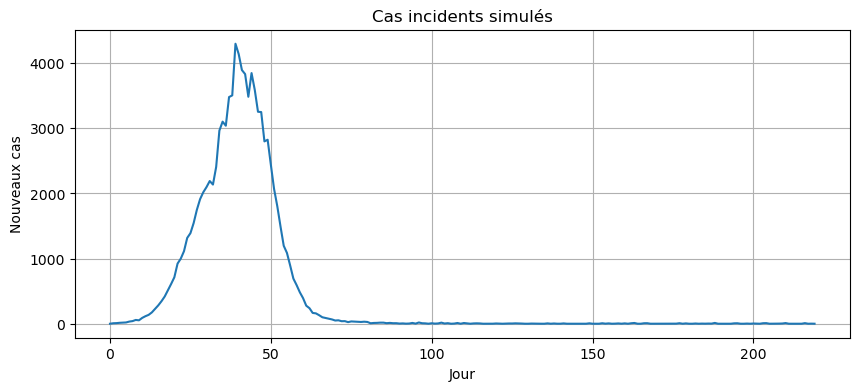

In [17]:
# Visualisation des cas incidents simulés

plt.figure(figsize=(10, 4))
plt.plot(df["day"], df["incidence"])
plt.title("Cas incidents simulés")
plt.xlabel("Jour")
plt.ylabel("Nouveaux cas")
plt.grid(True)
plt.show()

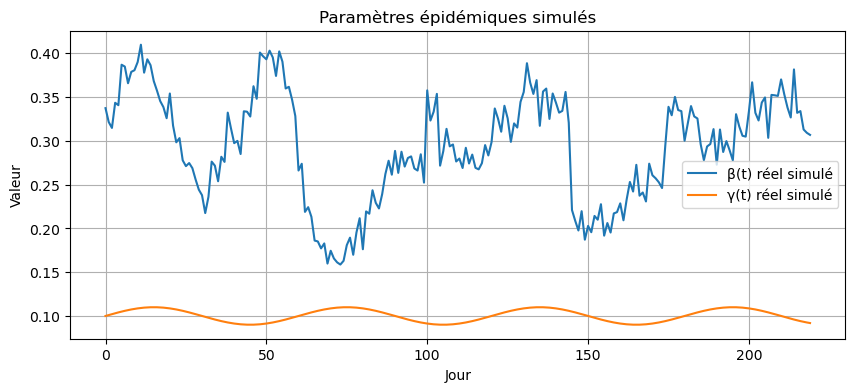

In [19]:
# Visualisation des paramètres réels simulés

plt.figure(figsize=(10, 4))
plt.plot(df["day"], df["beta_true"], label="β(t) réel simulé")
plt.plot(df["day"], df["gamma_true"], label="γ(t) réel simulé")
plt.title("Paramètres épidémiques simulés")
plt.xlabel("Jour")
plt.ylabel("Valeur")
plt.legend()
plt.grid(True)
plt.show()

## 2.1 Préparation des séquences

On utilise les 21 derniers jours pour prédire les 14 jours suivants.

Variables d’entrée :

- incidence passée ;
- température ;
- mobilité ;
- mesures sanitaires.

Variable cible :

- incidence future sur 14 jours.

In [21]:
def create_sequences(df, window=21, horizon=14):
    feature_cols = ["incidence", "temperature", "mobility", "measures"]
    target_col = "incidence"

    X = []
    y = []
    y0 = []

    for i in range(window, len(df) - horizon):
        past_features = df[feature_cols].iloc[i - window:i].values
        future_cases = df[target_col].iloc[i:i + horizon].values
        initial_state = df[["S", "I", "R"]].iloc[i].values

        X.append(past_features)
        y.append(future_cases)
        y0.append(initial_state)

    X = torch.tensor(np.array(X), dtype=torch.float32)
    y = torch.tensor(np.array(y), dtype=torch.float32)
    y0 = torch.tensor(np.array(y0), dtype=torch.float32)

    return X, y, y0


X, y, y0 = create_sequences(df, window=WINDOW, horizon=HORIZON)

n = len(X)
train_size = int(TRAIN_RATIO * n)

X_train = X[:train_size]
y_train = y[:train_size]
y0_train = y0[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]
y0_test = y0[train_size:]

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("y0_train :", y0_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)
print("y0_test :", y0_test.shape)

X_train : torch.Size([138, 21, 4])
y_train : torch.Size([138, 14])
y0_train : torch.Size([138, 3])
X_test : torch.Size([47, 21, 4])
y_test : torch.Size([47, 14])
y0_test : torch.Size([47, 3])


# Étape 3 — Entraînement du modèle hybride

La fonction de perte est composée de deux parties :

1. **MSE** entre les cas prédits et les cas observés ;
2. **Régularisation** sur β et γ pour éviter des paramètres trop extrêmes.

In [23]:
def train_hybrid_model(model, X_train, y_train, y0_train, epochs=500, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    for epoch in range(epochs):
        model.train()

        optimizer.zero_grad()

        pred, beta, gamma = model(X_train, y0_train)

        mse_loss = F.mse_loss(pred, y_train)

        # Régularisation légère des paramètres
        reg_loss = 1e-4 * (torch.mean(beta ** 2) + torch.mean(gamma ** 2))

        loss = mse_loss + reg_loss

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if epoch % 100 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"Loss={loss.item():.4f} | "
                f"MSE={mse_loss.item():.4f}"
            )

    return losses


hybrid_model = HybridLSTMSIR(
    input_dim=X.shape[2],
    hidden_dim=64,
    N=N_POP,
    horizon=HORIZON,
    dropout=0.2
)

hybrid_losses = train_hybrid_model(
    model=hybrid_model,
    X_train=X_train,
    y_train=y_train,
    y0_train=y0_train,
    epochs=500,
    lr=1e-3
)

Epoch 000 | Loss=1436359.0000 | MSE=1436359.0000
Epoch 100 | Loss=196276.1719 | MSE=196276.1719
Epoch 200 | Loss=64909.4102 | MSE=64909.4102
Epoch 300 | Loss=38232.1406 | MSE=38232.1406
Epoch 400 | Loss=56950.8984 | MSE=56950.8984


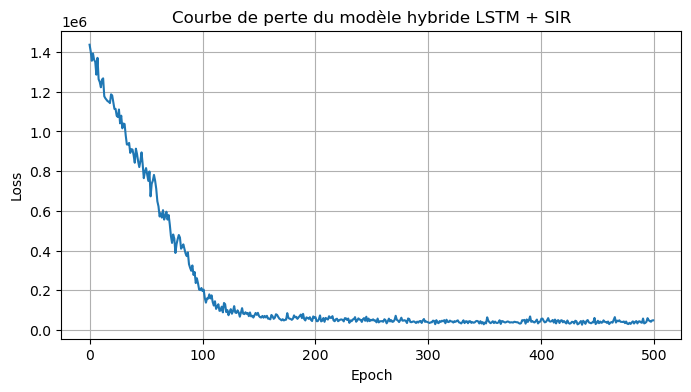

In [25]:
plt.figure(figsize=(8, 4))
plt.plot(hybrid_losses)
plt.title("Courbe de perte du modèle hybride LSTM + SIR")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Étape 4 — Comparaison avec les modèles de référence

On compare le modèle hybride avec :

1. **un LSTM pur**, qui prédit directement les cas futurs ;
2. **un SIR classique**, qui utilise des paramètres β et γ globaux.

## 4.1 Modèle LSTM pur

Le LSTM pur ne contient aucune structure épidémiologique.  
Il reçoit les données historiques et prédit directement les cas incidents futurs.

In [27]:
class PureLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, horizon=14, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        last_hidden = self.dropout(last_hidden)

        pred = self.fc(last_hidden)

        return torch.clamp(pred, min=0)


def train_lstm_model(model, X_train, y_train, epochs=500, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    for epoch in range(epochs):
        model.train()

        optimizer.zero_grad()

        pred = model(X_train)
        loss = F.mse_loss(pred, y_train)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if epoch % 100 == 0:
            print(f"Epoch {epoch:03d} | Loss={loss.item():.4f}")

    return losses


lstm_model = PureLSTM(
    input_dim=X.shape[2],
    hidden_dim=64,
    horizon=HORIZON,
    dropout=0.2
)

lstm_losses = train_lstm_model(
    model=lstm_model,
    X_train=X_train,
    y_train=y_train,
    epochs=500,
    lr=1e-3
)

Epoch 000 | Loss=1740321.8750
Epoch 100 | Loss=1731323.5000
Epoch 200 | Loss=1721866.0000
Epoch 300 | Loss=1713331.0000
Epoch 400 | Loss=1705644.0000


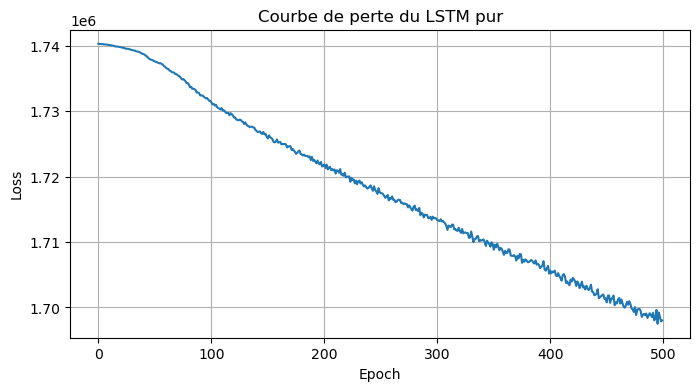

In [29]:
plt.figure(figsize=(8, 4))
plt.plot(lstm_losses)
plt.title("Courbe de perte du LSTM pur")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## 4.2 Modèle SIR classique recalibré

Le SIR classique utilise des paramètres β et γ globaux, appris à partir des données d’entraînement.

Contrairement au modèle hybride, il ne dépend pas directement des variables exogènes comme la mobilité ou les mesures sanitaires.

In [31]:
class ClassicalSIR(nn.Module):
    def __init__(self, N=100000, horizon=14):
        super().__init__()

        self.beta_raw = nn.Parameter(torch.tensor(0.2))
        self.gamma_raw = nn.Parameter(torch.tensor(0.1))

        self.N = N
        self.horizon = horizon

    def forward(self, y0):
        beta = F.softplus(self.beta_raw).repeat(y0.shape[0])
        gamma = F.softplus(self.gamma_raw).repeat(y0.shape[0])

        pred = euler_sir_forecast(
            y0=y0,
            beta=beta,
            gamma=gamma,
            N=self.N,
            horizon=self.horizon
        )

        return pred, beta, gamma


def train_classical_sir(model, y0_train, y_train, epochs=500, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    for epoch in range(epochs):
        model.train()

        optimizer.zero_grad()

        pred, beta, gamma = model(y0_train)

        loss = F.mse_loss(pred, y_train)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if epoch % 100 == 0:
            print(f"Epoch {epoch:03d} | Loss={loss.item():.4f}")

    return losses


sir_model = ClassicalSIR(
    N=N_POP,
    horizon=HORIZON
)

sir_losses = train_classical_sir(
    model=sir_model,
    y0_train=y0_train,
    y_train=y_train,
    epochs=500,
    lr=1e-3
)

Epoch 000 | Loss=1471800.3750
Epoch 100 | Loss=1333440.7500
Epoch 200 | Loss=1207640.7500
Epoch 300 | Loss=1090449.7500
Epoch 400 | Loss=980764.0625


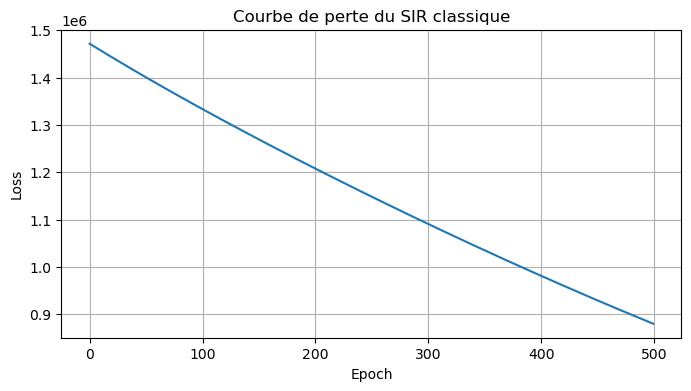

In [33]:
plt.figure(figsize=(8, 4))
plt.plot(sir_losses)
plt.title("Courbe de perte du SIR classique")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Livrable 1 — Courbes de prédiction moyenne ± écart-type

On utilise le **Monte Carlo Dropout** pour obtenir plusieurs prédictions possibles.

Principe :

- on garde le dropout actif au moment de la prédiction ;
- on répète la prédiction plusieurs fois ;
- on calcule la moyenne et l’écart-type des prédictions.

In [37]:
def mc_dropout_prediction_hybrid(model, X, y0, n_samples=100):
    '''
    Monte Carlo Dropout pour le modèle hybride.
    '''

    model.train()  # important : garde le dropout actif

    predictions = []

    with torch.no_grad():
        for _ in range(n_samples):
            pred, _, _ = model(X, y0)
            predictions.append(pred.unsqueeze(0))

    predictions = torch.cat(predictions, dim=0)

    mean_pred = predictions.mean(dim=0)
    std_pred = predictions.std(dim=0)

    return mean_pred, std_pred


mean_pred_hybrid, std_pred_hybrid = mc_dropout_prediction_hybrid(
    model=hybrid_model,
    X=X_test,
    y0=y0_test,
    n_samples=100
)

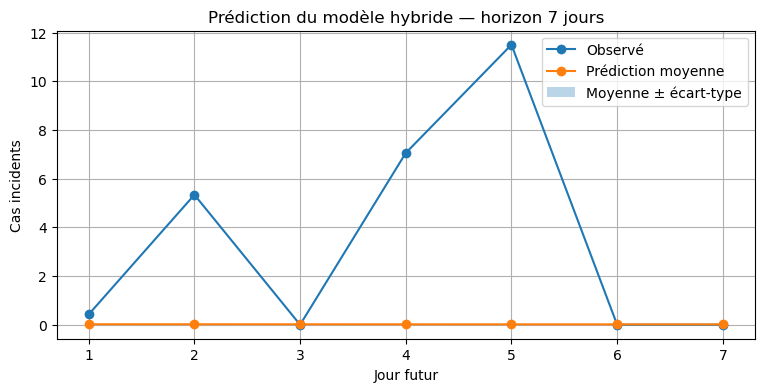

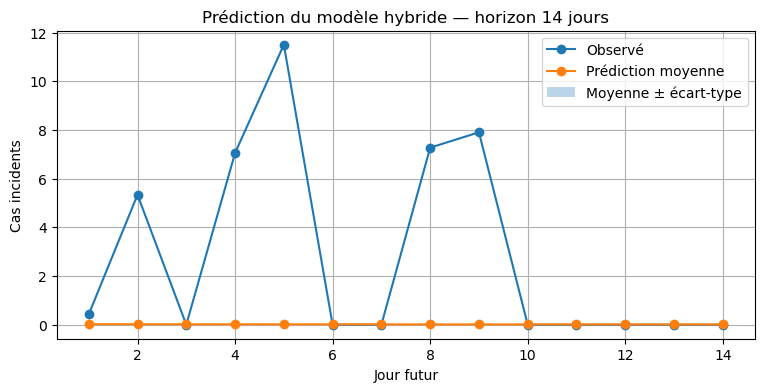

In [39]:
def plot_prediction_interval(y_true, mean_pred, std_pred, sample_id=0, horizon=14):
    days = np.arange(1, horizon + 1)

    observed = y_true[sample_id, :horizon].detach().numpy()
    mean_values = mean_pred[sample_id, :horizon].detach().numpy()
    std_values = std_pred[sample_id, :horizon].detach().numpy()

    plt.figure(figsize=(9, 4))
    plt.plot(days, observed, marker="o", label="Observé")
    plt.plot(days, mean_values, marker="o", label="Prédiction moyenne")

    plt.fill_between(
        days,
        mean_values - std_values,
        mean_values + std_values,
        alpha=0.3,
        label="Moyenne ± écart-type"
    )

    plt.title(f"Prédiction du modèle hybride — horizon {horizon} jours")
    plt.xlabel("Jour futur")
    plt.ylabel("Cas incidents")
    plt.legend()
    plt.grid(True)
    plt.show()


# Courbe à horizon 7 jours
plot_prediction_interval(
    y_true=y_test,
    mean_pred=mean_pred_hybrid,
    std_pred=std_pred_hybrid,
    sample_id=0,
    horizon=7
)

# Courbe à horizon 14 jours
plot_prediction_interval(
    y_true=y_test,
    mean_pred=mean_pred_hybrid,
    std_pred=std_pred_hybrid,
    sample_id=0,
    horizon=14
)

# Livrable 2 — Tableau comparatif des erreurs RMSE et MAE

On compare les performances des trois modèles sur deux horizons :

- horizon 7 jours ;
- horizon 14 jours.

In [41]:
def compute_metrics(y_true, y_pred, horizon):
    '''
    Calcule RMSE et MAE sur un horizon donné.
    '''

    y_true_np = y_true[:, :horizon].detach().numpy().reshape(-1)
    y_pred_np = y_pred[:, :horizon].detach().numpy().reshape(-1)

    rmse = np.sqrt(mean_squared_error(y_true_np, y_pred_np))
    mae = mean_absolute_error(y_true_np, y_pred_np)

    return rmse, mae


hybrid_model.eval()
lstm_model.eval()
sir_model.eval()

with torch.no_grad():
    pred_hybrid, beta_hat, gamma_hat = hybrid_model(X_test, y0_test)
    pred_lstm = lstm_model(X_test)
    pred_sir, beta_sir, gamma_sir = sir_model(y0_test)


results = []

models_predictions = [
    ("LSTM + SIR hybride", pred_hybrid),
    ("LSTM pur", pred_lstm),
    ("SIR classique", pred_sir)
]

for model_name, pred in models_predictions:
    rmse_7, mae_7 = compute_metrics(y_test, pred, horizon=7)
    rmse_14, mae_14 = compute_metrics(y_test, pred, horizon=14)

    results.append({
        "Modèle": model_name,
        "RMSE 7j": rmse_7,
        "MAE 7j": mae_7,
        "RMSE 14j": rmse_14,
        "MAE 14j": mae_14
    })

results_df = pd.DataFrame(results)

results_df

,Modèle,RMSE 7j,MAE 7j,RMSE 14j,MAE 14j
0,LSTM + SIR hybride,4.088181,2.293320,3.948172,2.170833
1,LSTM pur,3.589463,2.885278,3.514308,2.792194
2,SIR classique,4.089202,2.292804,3.949312,2.170084


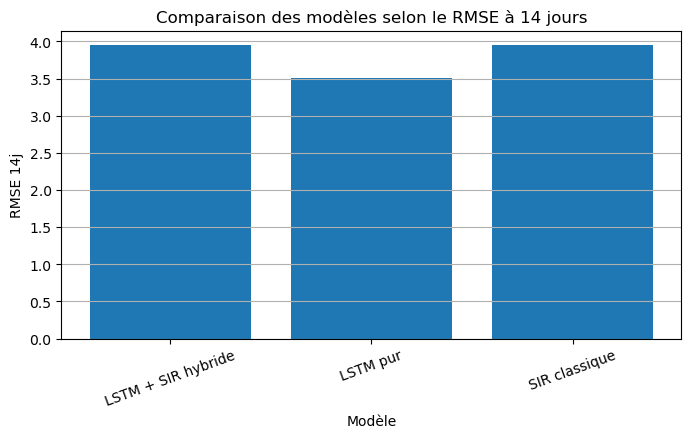

In [43]:
# Visualisation comparative simple du RMSE à 14 jours

plt.figure(figsize=(8, 4))
plt.bar(results_df["Modèle"], results_df["RMSE 14j"])
plt.title("Comparaison des modèles selon le RMSE à 14 jours")
plt.xlabel("Modèle")
plt.ylabel("RMSE 14j")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

# Livrable 3 — Discussion sur l’interprétabilité

Le modèle SIR classique est interprétable, car il repose sur une logique épidémiologique claire. Il permet de suivre l’évolution des compartiments S, I et R, ainsi que les paramètres β et γ.

Cependant, le SIR classique est limité lorsqu’il suppose que β et γ sont constants ou simplement recalibrés. Dans la réalité, le taux de transmission varie selon plusieurs facteurs : mobilité, saisonnalité, comportements sociaux, mesures sanitaires, adhésion aux consignes, etc.

Le LSTM pur est plus flexible, car il peut apprendre des relations complexes dans les données. Mais il est moins interprétable, car il prédit directement les cas futurs sans expliquer clairement les mécanismes de transmission.

Le modèle hybride LSTM + SIR combine les deux approches. Le LSTM apprend les variations temporelles des paramètres β(t) et γ(t), tandis que le SIR impose une structure épidémiologique cohérente.

Ainsi, le RNN capture ce que le SIR seul ne capture pas :

1. les effets non linéaires de la mobilité sur la transmission ;
2. l’effet retardé des mesures sanitaires ;
3. les variations temporelles du taux de transmission ;
4. les changements de comportement de la population ;
5. les interactions entre les cas passés, la mobilité, la température et les mesures.

En résumé, le RNN apprend les facteurs dynamiques et contextuels qui font varier β(t) et γ(t), tandis que le SIR garantit que la prédiction respecte une logique épidémiologique.

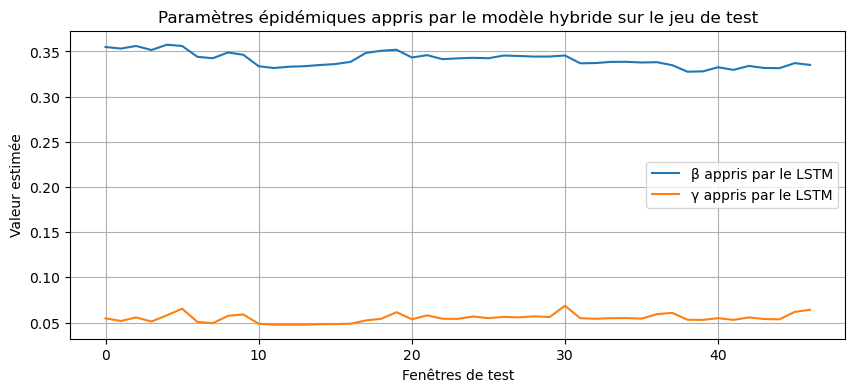

In [45]:
# Visualisation des paramètres appris par le modèle hybride

plt.figure(figsize=(10, 4))
plt.plot(beta_hat.detach().numpy(), label="β appris par le LSTM")
plt.plot(gamma_hat.detach().numpy(), label="γ appris par le LSTM")
plt.title("Paramètres épidémiques appris par le modèle hybride sur le jeu de test")
plt.xlabel("Fenêtres de test")
plt.ylabel("Valeur estimée")
plt.legend()
plt.grid(True)
plt.show()

# Conclusion du notebook

Ce notebook a permis de traiter les quatre étapes principales du projet :

- implémentation du modèle hybride LSTM + SIR ;
- génération de données simulées avec β(t) variable et bruité ;
- entraînement du modèle hybride avec perte MSE et régularisation ;
- comparaison avec un LSTM pur et un SIR classique.

Les livrables complémentaires ont également été produits :

- courbes de prédiction avec moyenne ± écart-type ;
- tableau comparatif RMSE et MAE ;
- discussion sur l’interprétabilité.

Après exécution du notebook, les résultats numériques du tableau RMSE/MAE pourront être intégrés dans un rapport Word avec les interprétations.